# Compact regex execution graph

This notebook builds both the full and representative-domain forms of a regex with `CompactRegexGraphBuilder`. It removes parser-only wrapper nodes and displays each compact generation path from `START` to `END`. Change `PATTERN` or `SEED` and rerun all cells to visualize another regex.

In [37]:
from pathlib import Path
import string
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "regex_positive_generator").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the regex_testing workspace.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from regex_positive_generator.experimental import CompactRegexGraphBuilder
from regex_positive_generator.experimental.compact_sampler import CompactGraphSampler

PATTERN = r"([A-Z]{1,10})\d{5}\1"
FLAGS = 0
SEED = 21  # Produces repeat representatives 1, 5, 10 for {1,10}.
FIGSIZE = (12, 5)
FONT_SIZE = 18
OUTPUT_PATH = None  # Example: Path("compact_regex_execution_graph.pdf")

plt.rcParams.update({"font.family": "serif", "font.size": FONT_SIZE})

In [38]:
STAGE_STYLES = {
    "terminal": {"facecolor": "#F2F3F4", "edgecolor": "#566573"},
    "capture": {"facecolor": "#E8F6F3", "edgecolor": "#148F77"},
    "class": {"facecolor": "#EAF7EA", "edgecolor": "#3B7D3A"},
    "backreference": {"facecolor": "#FDEDEC", "edgecolor": "#B03A2E"},
    "semantic": {"facecolor": "#F4ECF7", "edgecolor": "#7D3C98"},
    "literal": {"facecolor": "#FEF5E7", "edgecolor": "#CA6F1E"},
}


def class_text(payload):
    chars = set(payload or ())
    known = [
        (set(string.ascii_uppercase), "[A-Z]"),
        (set(string.ascii_lowercase), "[a-z]"),
        (set(string.ascii_letters), "[A-Za-z]"),
        (set(string.digits), "[0-9]"),
        (set(string.ascii_letters + string.digits + "_"), r"\w"),
    ]
    for expected, label in known:
        if chars == expected:
            return label
    if len(chars) <= 3:
        return "[" + ", ".join(sorted(chars)) + "]"
    if len(chars) <= 12:
        return "[" + "".join(sorted(chars)) + "]"
    return f"class ({len(chars)} characters)"


def repeat_text(bounds):
    if bounds is None:
        return None
    if len(bounds) == 1:
        return f"repeat = {bounds[0]}"
    if len(bounds) > 2:
        return "repeat = " + ", ".join(str(value) for value in bounds)
    minimum, maximum = bounds
    if minimum == maximum:
        return f"repeat = {minimum}"
    return f"repeat = {minimum}..{maximum}"


def leaf_stage(node, repeat_bounds=None):
    if node.kind == "class":
        return {"kind": "class", "lines": [f"class {class_text(node.payload)}"]}
    if node.kind == "literal":
        return {"kind": "literal", "lines": ["literal", repr(node.payload)]}
    if node.kind == "backref":
        return {
            "kind": "backreference",
            "lines": [fr"backreference \{node.payload}", f"replay group {node.payload}"],
        }
    if node.kind == "anchor":
        return {"kind": "semantic", "lines": ["anchor", str(node.payload)]}
    if node.kind == "lookaround":
        return {"kind": "semantic", "lines": ["lookaround"]}
    return {"kind": "semantic", "lines": [node.kind]}


def flatten_execution_stages(node, repeat_bounds=None):
    # Sequence nodes only order their children; they are not displayed.
    if node.kind in {"sequence", "passthrough"}:
        stages = []
        for child in node.children:
            stages.extend(flatten_execution_stages(child, repeat_bounds=repeat_bounds))
        return stages

    # A repeat around one semantic element is folded into that element.
    if node.kind == "repeat":
        bounds = (node.min_rep, node.max_rep)
        stages = flatten_execution_stages(node.children[0], repeat_bounds=bounds)
        if len(stages) == 1:
            stages[0]["repeat"] = bounds
        else:
            for stage in stages:
                stage.setdefault("repeat_group", bounds)
        return stages

    # Capture metadata is attached to the generated stage instead of
    # showing separate group-start/group-end wrapper nodes.
    if node.kind == "group":
        stages = flatten_execution_stages(node.children[0], repeat_bounds=repeat_bounds)
        if stages:
            stages[0]["capture_start"] = node.payload
            stages[-1]["capture_end"] = node.payload
            if len(stages) == 1:
                stages[0]["kind"] = "capture"
        return stages

    stage = leaf_stage(node, repeat_bounds=repeat_bounds)
    if repeat_bounds is not None:
        stage["repeat"] = repeat_bounds
    return [stage]


def apply_representative_repeats(stages, builder, seed):
    sampler = CompactGraphSampler(builder, validate=True)
    sampler.seed = seed
    representative_counts = iter(
        sampler._repeat_representatives(node)
        for node in builder.nodes
        if node.kind == "repeat"
    )
    for stage in stages:
        if stage.get("repeat") is not None:
            stage["repeat"] = next(representative_counts)
    return stages


def stage_label(stage):
    lines = list(stage["lines"])
    repeated = repeat_text(stage.get("repeat"))
    if repeated:
        lines.append(repeated)
    if stage.get("capture_start") == stage.get("capture_end") and stage.get("capture_start") is not None:
        lines.append(f"capture group {stage['capture_start']}")
    elif stage.get("capture_start") is not None:
        lines.append(f"start capture {stage['capture_start']}")
    elif stage.get("capture_end") is not None:
        lines.append(f"end capture {stage['capture_end']}")
    return "\n".join(lines)

In [39]:
full_builder = CompactRegexGraphBuilder(PATTERN, flags=FLAGS, validate=True)
simplified_builder = full_builder.build_simplified_graph(seed=SEED)
sample_semantic_stages = apply_representative_repeats(
    flatten_execution_stages(simplified_builder.root),
    simplified_builder,
    SEED,
)
execution_stages = [
    {"kind": "terminal", "lines": ["START"]},
    *sample_semantic_stages,
    {"kind": "terminal", "lines": ["END"]},
]

print(f"Regex: {PATTERN}")
print(f"Representative-domain seed: {SEED}")
print("Simplified execution stages:")
for index, stage in enumerate(execution_stages):
    print(f"{index}: {stage_label(stage).replace(chr(10), ' | ')}")

Regex: ([A-Z]{1,10})\d{5}\1
Representative-domain seed: 21
Simplified execution stages:
0: START
1: class [A, J, Z] | repeat = 1, 5, 10 | capture group 1
2: class [0, 2, 9] | repeat = 5
3: backreference \1 | replay group 1
4: END


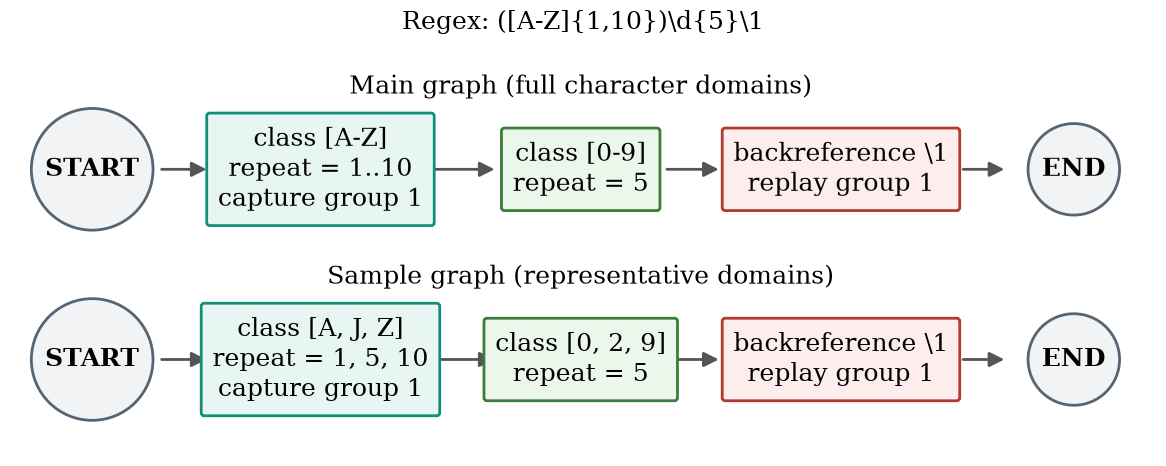

In [41]:
def stage_positions(count):
    # Tuned for five semantic stages at 18 pt while remaining usable for
    # shorter or longer compact paths.
    if count == 5:
        return [0.0, 2.5, 5.35, 8.2, 10.75]
    if count == 1:
        return [0.0]
    spacing = 10.75 / (count - 1)
    return [index * spacing for index in range(count)]


def stage_margin(stage):
    # Arrow shrink distances in points, matched to the rendered box widths.
    return {
        "terminal": 50,
        "capture": 82,
        "class": 62,
        "backreference": 88,
        "semantic": 72,
        "literal": 62,
    }[stage["kind"]]


def execution_stages_for(builder, representative_seed=None):
    semantic_stages = flatten_execution_stages(builder.root)
    if representative_seed is not None:
        semantic_stages = apply_representative_repeats(
            semantic_stages, builder, representative_seed
        )
    return [
        {"kind": "terminal", "lines": ["START"]},
        *semantic_stages,
        {"kind": "terminal", "lines": ["END"]},
    ]


def draw_execution_row(
    ax, builder, y, row_label, font_size=18, representative_seed=None
):
    stages = execution_stages_for(builder, representative_seed=representative_seed)
    xs = stage_positions(len(stages))
    ax.text(
        5.35,
        y + 0.58,
        row_label,
        fontsize=font_size,
        # fontweight="bold",
        ha="center",
        va="center",
    )

    for index, (left, right) in enumerate(zip(xs, xs[1:])):
        ax.add_patch(
            FancyArrowPatch(
                (left, y),
                (right, y),
                arrowstyle="-|>",
                mutation_scale=22,
                linewidth=2.0,
                color="#555555",
                shrinkA=stage_margin(stages[index]),
                shrinkB=stage_margin(stages[index + 1]),
                zorder=1,
            )
        )

    for x, stage in zip(xs, stages):
        style = STAGE_STYLES[stage["kind"]]
        terminal = stage["kind"] == "terminal"
        ax.text(
            x,
            y,
            stage_label(stage),
            fontsize=font_size,
            fontweight="bold" if terminal else "normal",
            ha="center",
            va="center",
            bbox={
                "boxstyle": "circle,pad=0.55" if terminal else "round,pad=0.45,rounding_size=0.12",
                "facecolor": style["facecolor"],
                "edgecolor": style["edgecolor"],
                "linewidth": 2.0,
            },
            zorder=3,
        )

    return stages


def draw_comparison_graph(
    full_builder,
    simplified_builder,
    seed,
    figsize=(10, 4),
    font_size=18,
    output_path=None,
):
    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    draw_execution_row(
        ax,
        full_builder,
        y=0.67,
        row_label="Main graph (full character domains)",
        font_size=font_size,
    )
    draw_execution_row(
        ax,
        simplified_builder,
        y=-0.67,
        row_label=f"Sample graph (representative domains)",
        font_size=font_size,
        representative_seed=seed,
    )
    ax.set_xlim(-0.9, 11.65)
    ax.set_ylim(-1.35, 1.60)
    ax.set_title(f"Regex: {full_builder.regex}", fontsize=font_size)
    ax.axis("off")
    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight", dpi=300, facecolor="white")
        print(f"Saved: {output_path.resolve()}")
    return fig, ax


fig, ax = draw_comparison_graph(
    full_builder,
    simplified_builder,
    seed=SEED,
    figsize=FIGSIZE,
    font_size=FONT_SIZE,
    output_path=OUTPUT_PATH,
)
# plt.savefig("compact_regex_execution_graph.pdf", bbox_inches="tight", dpi=1200, facecolor="white")
plt.show()